In [1]:
from __future__ import annotations
import pandas as pd
import json
import ijson
from urllib.request import urlopen
import pandas as pd
import numpy as np
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import statistics
from cvss import CVSS3
import pyzstd 
import matplotlib.patches as mpatches
import multiprocessing as mp


from typing import TypeVar, Generic
import copy 
from datetime import datetime

plt.style.use('ggplot') 
plt.rcParams['figure.facecolor'] = 'white'
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [24]:
data_path= 'FINAL_SWH_OSV/data/'
result_path = f"{data_path}TRACKING_SECTION_3_ANALYSIS/"

metrics_2_path= f"{result_path}Metric2.json"
metrics_3_path= f"{result_path}Metrics34.jsonl"
metrics_3_list_path= f"{result_path}urlist.json"
metrics_5_path= f"{data_path}RQ_SECTION_4_ANALYSIS/Metric5.jsonl.zst"

metadata_path= f"{data_path}RQ_SECTION_4_ANALYSIS/origin-metadata.csv.zst"

analysis_out_path=f"{result_path}/analysis/"
#create output directory if it does not exist
import os
if not os.path.exists(analysis_out_path):
    os.makedirs(analysis_out_path)

In [3]:
class RepoMetadata:
    def __init__(self, origin:str,url:str,isFork:bool,stars:int,forks:int):
        self.origin=origin
        self.url=url
        self.isFork=isFork
        self.stars=stars
        self.forks=forks

    def to_string(self):
        return f"{self.origin},{self.url},{self.isFork},{self.stars},{self.forks}"

class ReposMetadata:
    reposMaps:dict[str,RepoMetadata]
    metadata_path:str
    skipped_repo : list[str] = []
    def __init__(self,metadata_path:str,out= analysis_out_path):
        self.reposMaps={}
        self.metadata_path=metadata_path
        self.output_path:str = f"{out}reposMetadata_final.json"

    
    def load_metadata_from_zst_csv(self,url_to_fetch:set[str]):
        self.reposMaps={}
        with pyzstd.open(metadata_path, "rb") as f:
            for line in f:
                line = line.decode("utf-8")
                line = line.split(",")
                url=line[1].replace('"""','')
                if url in url_to_fetch:
                    self.reposMaps[url]=RepoMetadata(line[0],url,line[2]=="True",int(line[3]),int(line[4]))
                else :
                    self.skipped_repo.append(url)
        print(f"Found {len(self.reposMaps)} skipp {len(self.skipped_repo)}")

    def count_fork(self):
        total_repo=0
        fork=0
        with pyzstd.open(metadata_path, "rb") as f:
            for line in f:
                total_repo+=1
                line = line.decode("utf-8")
                line = line.split(",")
                url=line[1].replace('"""','')
                if line[2].lower()=="true":
                    fork+=1
        print(f"{fork} forks out of {total_repo}")

    def export_to_json(self):
        with open(self.output_path, 'w') as f:
            json.dump({k: v.__dict__ for k, v in self.reposMaps.items()}, f, indent=4)
    
    def load_from_json()->ReposMetadata:
        with open(ReposMetadata.output_path, 'r') as f:
            data = json.load(f)
            ReposMetadata.reposMaps = {k: RepoMetadata(**v) for k, v in data.items()}
        print(f"Loaded {len(ReposMetadata.reposMaps)} repos from {ReposMetadata.output_path}")

reposMetadata=ReposMetadata(metadata_path)


In [5]:
T = TypeVar('T')
    
class RangeFilter(Generic[T]):
    def filter(self,item : T)-> bool:
        return True

class ForkFilter():
    def filter(self, forkUrl : str)->bool:
        return True 


class Metric :
    def __init__(self, range_filter: RangeFilter =RangeFilter(), fork_filter: ForkFilter = ForkFilter()):
        self.range_filter = range_filter
        self.fork_filter = fork_filter

    def plot() -> Metric:
        return self
        
    def compute() -> Metric:
        return self
    def format_number(sel,number):
        return f"{number:,}".replace(",", " ")
    '''
    Create a function that takes a set of urls and returns the top n forges with the number of urls for each forge
    '''
    def _get_top_n_forges(self,url_set,n):
        result = []
        for url in url_set :
                try:
                        url_parsed = urlparse(url)
                        domain = url_parsed.netloc 
                        domain = 'googlecode.com' if 'googlecode.com' in url_parsed.netloc else domain
                        domain = 'googlesource.com' if 'googlesource.com' in url_parsed.netloc else domain
                except Exception as e:
                        print(f"Error parsing url {url} : {e}")
                        continue
                result.append([domain, url_parsed.scheme])


        df=pd.DataFrame(result, columns=['Forge', 'Scheme']).groupby(['Forge', 'Scheme']).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
        top_n = df if n==-1 else df.nlargest(n, 'Count')[::-1]
        total_count = df['Count'].sum()
        top_n_count = top_n['Count'].sum()
        other_count = total_count - top_n_count
        other_df = pd.DataFrame({'Forge': [f'Other ({len(df.index)-n} sources)'], 'Count': [other_count]})
        final_df = pd.concat([other_df,top_n.sort_values(by='Count', ascending=False)])

        return final_df


class CriticityRangeFilter(RangeFilter[str]):
    def __init__(self, min: float):
        super().__init__()
        self.min = min

    def filter(self, item:str) -> bool:
        if(item is None or item == ''):
            return False
        else:
            score = CVSS3(item).base_score 
            return score is not None and score > self.min

class MetadataForkFilter(ForkFilter):
    def __init__(self, repos_metadata : ReposMetadata, min_star : int, min_fork: int):
        super().__init__()
        self.min_star = min_star
        self.min_fork = min_fork
        self.repos_metadata = repos_metadata
    
    def filter(self, forkUrl : str)->bool:
        if forkUrl in self.repos_metadata.reposMaps : 
            metadata:RepoMetadata=self.repos_metadata.reposMaps[forkUrl]
            return metadata.stars> self.min_star and metadata.forks >  self.min_fork
        else :
            #print(f"Skipping {forkUrl} ,no metadata available")
            return False

    



## Commits level analysis : Vulnerable commits only located in fork ( not detected by tools such as OSV )
 


In [25]:
import matplotlib.patches as mpatches

class Metric_2(Metric):

    def __init__(self, range_filter: RangeFilter | None =None):
        self.new_vulnerable_revision_nb_per_range = []
        self.old_revision_nb_per_range = set()
        self.m2_share_df : pd.DataFrame = pd.DataFrame()
        ##ToDo remove manual update from provenance compute log, add proper file(old execution : 142615331 )
        self.distinct_affected_rev_nb=158878571
        self.new_distinct_affected_rev=0
        super().__init__(range_filter)
    
    def compute(self):
        self.new_vulnerable_revision_nb_per_range = []
        self.old_revision_nb_per_range = []
        distinct_vulnerated_rev = set()
        with open(metrics_2_path) as f:
            metric_2_iterator = ijson.items(f, 'item')
            for row in metric_2_iterator :
                if(self.range_filter is None or self.range_filter.filter(row['range']['severity'])):
                    metadata = row['metadata']
                    old_revision_nb = metadata['old_vulnerable_revision_number']
                    if old_revision_nb == 0:
                        print(f'No original vulnerable revision for {row["range"]}')
                    else :
                        new_vulnerable_rev= metadata['new_vulnerable_revision']
                        distinct_vulnerated_rev.update(new_vulnerable_rev)
                        self.new_vulnerable_revision_nb_per_range.append(len(new_vulnerable_rev))
                        self.old_revision_nb_per_range.append(old_revision_nb)
        self.new_distinct_affected_rev = len(distinct_vulnerated_rev)
        m2_share_data = {'new_vulnerable_rev_nb':self.new_vulnerable_revision_nb_per_range,'old_vulnerable_rev_nb':self.old_revision_nb_per_range}

        # Create DataFrame
        self. m2_share_df = pd.DataFrame(m2_share_data)
        self.m2_share_df['new_vulnerable_rev_ratio'] = round((self.m2_share_df['new_vulnerable_rev_nb']/self.m2_share_df['old_vulnerable_rev_nb']),2)
        return self
    def format_number(sel,number):
        return f"{number:,}".replace(",", " ")
    def plot(self):
        ########## Bar Chart ##########
        m2_pie_data_2 = {
            'Category': [
                'Upstream repositories',
                'Associated forks'
            ],
            'Values': [
                self.distinct_affected_rev_nb - self.new_distinct_affected_rev,
                 self.new_distinct_affected_rev,
            ]
        }

        default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]
        # Create bar chart
        fig1, ax1=plt.subplots(figsize=(8.45, 1.7))  # Adjusted figure size
        bars = plt.barh(
            m2_pie_data_2['Category'],
            m2_pie_data_2['Values'],
            color=default_colors,
            edgecolor='black',
            height=0.4
        )
        x_min, x_max = plt.gca().get_xlim()
        plt.gca().set_xlim(x_min, x_max + 0.2*x_max)

        # Add value annotations on bars
        for index, value in enumerate(m2_pie_data_2['Values']):
            formatted_value = f"{value:,}".replace(',', ' ')
            ax1.text(
                value + 0.5,
                index,
                formatted_value,
                va='center',
                ha='left'
            )
        plt.tight_layout()
        fig1.show()
        fig1.savefig(f"{result_path}metric2_bar.pdf", bbox_inches='tight')


        ########## Boxplot ##########
        fig2, ax2=plt.subplots(figsize=(10.3, 1.2))
        
        plt.boxplot(self.m2_share_df['new_vulnerable_rev_ratio'], showfliers=False,vert=False, widths=0.20)
        q1 = round(np.percentile(self.m2_share_df['new_vulnerable_rev_ratio'], 25), 3)
        median = round(np.percentile(self.m2_share_df['new_vulnerable_rev_ratio'], 50), 3)
        q3 = round(np.percentile(self.m2_share_df['new_vulnerable_rev_ratio'], 75), 3)
        _mean = round(np.mean(self.m2_share_df['new_vulnerable_rev_ratio']), 3)
        _max = round(np.max(self.m2_share_df['new_vulnerable_rev_ratio']),3)
        sigma = round(np.std(self.m2_share_df['new_vulnerable_rev_ratio']), 3)

        legend_labels = [
    f'Median: {median}',
    f'Q1: {q1}',
    f'Q3: {q3}',
    f'Mean: {_mean}',
    f'Max: {_max}',
    f'Std: {sigma}',
]
        # Create empty handles for the legend (invisible patches)
        handles = [mpatches.Patch(color='none') for _ in legend_labels]
        # Create the legend with 3 columns, placed at top right inside the plot
        ax2.legend(
            handles,
            legend_labels,
            loc='upper right',
            bbox_to_anchor=(1, 1),
            ncol=6,
            frameon=False,
            handlelength=0,  # no handles shown
            handletextpad=0,
            columnspacing=1.5  # no padding for handles
        )
        ax2.set_yticklabels([])  # remove y-tick labels as before
        ax2.set_ylabel('')
        plt.gca().set_yticklabels([])
        plt.gca().set_ylabel('')
        y_min, y_max = plt.gca().get_ylim()

        plt.gca().set_ylim(y_min+ 0.5*y_min, y_max )
    
        
        fig2.show()
        fig2.savefig(f"{result_path}metric2_box_plot.pdf", bbox_inches='tight')

        return self

In [ ]:
metric_2_ :Metric = Metric_2()
metric_2_.compute()

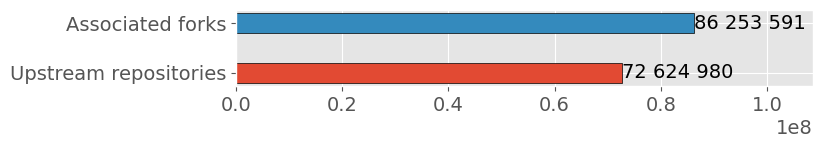

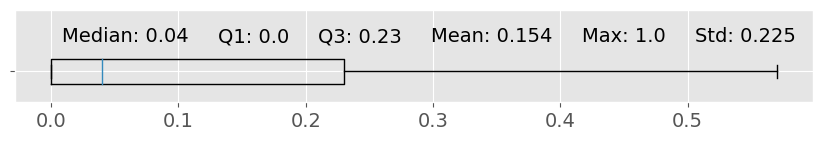

In [ ]:
metric_2_.plot()

## Repository level analysis : fork with at least a new vulnerable commit in their history (ie a commit that is not on upstream repository)

```[
    {
    "range":...,
    "metadata":
        {
        "url_to_new_vulnerable_revision":
            [
                {
                "urlIndex": x,  --> to be searched in metrics_3_list_path
                "vulnerable_revisions_number":x
                }
            ]
        }
    }
]

In [29]:

class Metric_3(Metric):

    def __init__(self,url_list_of_set, range_filter: RangeFilter  =RangeFilter(), fork_filter: ForkFilter  =ForkFilter()):
        self.url_list_of_set = url_list_of_set
        self.set_forks = set()
        self.set_original_repo = set()
        self.top_n_forges_df = pd.DataFrame()
        self.original_repo_2_forks = {}
        self.set_fork_cve = set()
        self.set_original_repo_cve = set()
        super().__init__(range_filter, fork_filter)
    def compute(self):
        
        with open(metrics_3_path, 'r') as file:
            for line in file:
                try:
                        obj = json.loads(line)
                        if not self.range_filter.filter(obj['range']['severity']):
                            continue
                        
                        range_urls=set(obj['range']['repo_url'])
                        self.set_original_repo.update(range_urls)
                        new_forks = set()
                        
                        url_to_new_vulnerable_revision= obj['metadata']['url_to_new_vulnerable_revision']
                        for mapping in url_to_new_vulnerable_revision:
                            if mapping["vulnerable_revisions_number"]>0:
                                urls = self.__get_origins(mapping["urlsIndex"])
                                
                                urls = filter(self.fork_filter.filter,urls)
                                
                                
                                new_forks.update(urls)
                            else :
                                raise Exception('No vulnerable revision')
                            
                        #Check if there is some old origin in new_origins set
                     
                        
                        for fork in new_forks:
                            self.set_fork_cve.add( (fork, obj['range']['vulnerability_id']) )

                        
                                   
                        for url in range_urls:
                            self.set_original_repo_cve.add( (url, obj['range']['vulnerability_id']) )
                            #self.set_fork_cve.add( (fork, obj['range']['vulnerability_id']) )
                            if url not in self.original_repo_2_forks:
                                self.original_repo_2_forks[url]=set()
                            self.original_repo_2_forks[url].update(new_forks)
                            
                        new_forks= new_forks-range_urls
                        self.set_forks.update(new_forks)
                            
                        
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON: {e}. Skipping line.")
                    continue 

        self.set_forks.discard(None)
        self.top_n_forges_df = self._get_top_n_forges(self.set_forks,10)
  
        return self
    
    def __get_origins(self,id):
        return self.url_list_of_set[id]
    def format_number(sel,number):
        return f"{number:,}".replace(",", " ")
    def plot(self):
        #create figure directory if it does not exist
        if not os.path.exists('figures'):
            os.makedirs('figures')
        ##########Pie chart##########
        fig1, ax1 = plt.subplots(figsize=(8.45, 1.5))
        #ax1.set_xscale('log')

        m1_share_data = {
            'Category': [
                'Forks',
                'Original repository'
            ],
            'Values': [len(self.set_forks), len(self.set_original_repo)]
        }

        # Plot horizontal bar chart
        bar_width = 0.4
        default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]

        bars = ax1.barh(
            m1_share_data['Category'],
            m1_share_data['Values'],
            edgecolor='black',
            height=bar_width,
            color=default_colors,
        )
        x_min, x_max = plt.gca().get_xlim()
        plt.gca().set_xlim(x_min, x_max + 0.1*x_max)

        # Customize appearance
        #ax1.set_xlabel('Number of vulnerable repositories')

        # Add value annotations on bars
        for index, value in enumerate(m1_share_data['Values']):
            formatted_value = f"{value:,}".replace(',', ' ')
            ax1.text(
                value + 0.5,
                index,
                formatted_value,
                va='center',
                ha='left'
            )


        # Remove legend
        ax1.legend().remove()

        # Adjust layout
        fig1.tight_layout()

        # Show and save the figure
        fig1.show()
        fig1.savefig(f"{result_path}metric3_bar.pdf", bbox_inches='tight')

      


        ##########Boxplot##########
        fig2, ax2 = plt.subplots(figsize=(9, 1.6))

        new_url_nb_per_original_repo_url = [len(value) for value in self.original_repo_2_forks.values()]

        ax2.boxplot(new_url_nb_per_original_repo_url, showfliers=False, vert=False, widths=0.20)
        # ax2.set_title('Number of forks containing a \n new vulnerable commits, by referenced repository ', pad=40)

        q1 = round(np.percentile(new_url_nb_per_original_repo_url, 25))
        median = round(np.percentile(new_url_nb_per_original_repo_url, 50))
        q3 = round(np.percentile(new_url_nb_per_original_repo_url, 75))
        _mean = round(np.mean(new_url_nb_per_original_repo_url))
        _max = np.max(new_url_nb_per_original_repo_url)
        sigma = round(np.std(new_url_nb_per_original_repo_url))

        legend_labels = [
    f'Median: {median}',
    f'Q1: {q1}',
    f'Q3: {q3}',
    f'Mean: {_mean}',
    f'Max: {_max}',
    f'Std: {sigma}',
]

        # Create empty handles for the legend (invisible patches)
        handles = [mpatches.Patch(color='none') for _ in legend_labels]

        # Create the legend with 3 columns, placed at top right inside the plot
        ax2.legend(
            handles,
            legend_labels,
            loc='upper right',
            bbox_to_anchor=(1, 1),
            ncol=6,
            frameon=False,
            handlelength=0,  # no handles shown
            handletextpad=0  # no padding for handles
        )

        ax2.set_yticklabels([])  # remove y-tick labels as before
        ax2.set_ylabel('')
        y_min, y_max = plt.gca().get_ylim()
        plt.gca().set_ylim(y_min+ 0.6*y_min, y_max )
        fig2.tight_layout()
        fig2.show()

        fig2.savefig(f"{result_path}metric3_box_plot.pdf", bbox_inches='tight')

        
        ##########Hist##########
        fig3, ax3 = plt.subplots(figsize=(8, 3.5))
        ax3.barh(self.top_n_forges_df['Forge'], self.top_n_forges_df['Count'], height=0.4)
        ax3.set_xlabel('Number of forks (Log Scale)')
        ax3.set_ylabel('Forges')
        ax3.set_xscale('log')  # Set x-axis to logarithmic scale
        ax3.tick_params(axis='y')
        fig3.show()

        # Save the figure
        fig3.savefig(f"{result_path}metric3_top.pdf", bbox_inches='tight')
        return self

In [8]:
print("loading list")
with open(metrics_3_list_path, 'r') as file:
    url_list_of_set=json.load(file)
print("loading list over")

loading list
loading list over


In [ ]:
metrics_3_unfiltered = Metric_3(url_list_of_set)
metrics_3_unfiltered.compute()


In [16]:
original_repo_fork_cve = set()

for original_repo, cve in metrics_3_unfiltered.set_original_repo_cve:
    if original_repo in metrics_3_unfiltered.original_repo_2_forks:
        forks = metrics_3_unfiltered.original_repo_2_forks[original_repo]
        for fork in forks:
            original_repo_fork_cve.add((original_repo, fork, cve))

print(f"Total theoretical (original_repo, fork, CVE) combinations: {len(original_repo_fork_cve)}")
print(f"Number of unique original repos: {len(metrics_3_unfiltered.set_original_repo)}")
print(f"Number of unique forks: {len(metrics_3_unfiltered.set_forks)}")
print(f"Number of unique (fork, CVE) actually found: {len(metrics_3_unfiltered.set_fork_cve)}")

Total theoretical (original_repo, fork, CVE) combinations: 1193607730
Number of unique original repos: 7162
Number of unique forks: 2270180
Number of unique (fork, CVE) actually found: 132189066


In [13]:
top_n_with_proportion = metrics_3_unfiltered.top_n_forges_df.copy()
total_count = top_n_with_proportion['Count'].sum()
top_n_with_proportion['Proportion'] = (top_n_with_proportion['Count'] / total_count * 100).round(2)
top_n_with_proportion

,Forge,Count,Scheme,Proportion
0,Other (302 sources),5661,NaN,0.25
203,github.com,2207476,https,97.24
213,gitlab.com,40357,https,1.78
6,bitbucket.org,5285,https,0.23
262,gitorious.org,2791,https,0.12
225,gitlab.freedesktop.org,1642,https,0.07
124,git.launchpad.net,1547,https,0.07
263,googlecode.com,1484,https,0.07
289,salsa.debian.org,1468,https,0.06
264,googlesource.com,1310,https,0.06


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


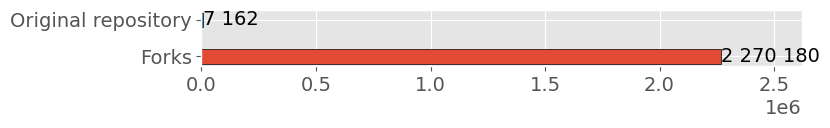

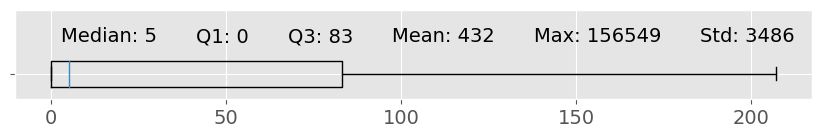

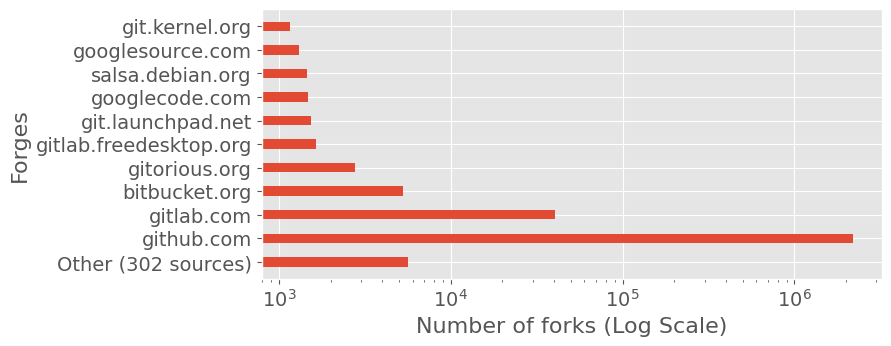

In [30]:
metrics_3_unfiltered.__class__=Metric_3
metrics_3_unfiltered.plot()

### Forks with unpatched head 

In [ ]:
import pyzstd
import itertools
import logging
from itertools import islice
from tqdm import tqdm

class Metric_5(Metric):

    def __init__(self, range_filter: RangeFilter = RangeFilter(), fork_filter:ForkFilter = ForkFilter()):
        super().__init__(range_filter,fork_filter)
        self.fork_url= set()
            
    def compute(self):   

            
        with pyzstd.open(metrics_5_path, 'r') as file:
            for line in file:
                        obj = json.loads(line)
                        unpatched_heads= obj['unpatched_heads']
                        if len(unpatched_heads)==0:
                            print("No unpatched heads")
                        forks = obj['urls']
                        self.fork_url.update(forks)
                        
        return self
    


    # def compute(self):   


    #     with pyzstd.open(metrics_5_path, 'rb') as file:
    #                 for line in file:
    #                     self.res.update(self.parse_json_line(line))
                           
           

    def plot(self,metrics_3_unfiltered_forks:set):
        fig1, ax1 = plt.subplots(figsize=(8.45, 1.7))

        if not os.path.exists('figures'):
            os.makedirs('figures')
        
        #self.fork_url contain all the forks with unpatched head, metrics_3_unfiltered_forks contain all the forks with a new vulnerable revision so some fork without a new vulnerable revision can have an unpatched head, we therfore filter them

        unpatched_forks_with_new_vuln_revision = self.fork_url.intersection(metrics_3_unfiltered_forks)

        data = {'Category': ['Forks having an unpatched head','Forks without unpatched head'],
                            'Values': [len(unpatched_forks_with_new_vuln_revision),len(metrics_3_unfiltered_forks - unpatched_forks_with_new_vuln_revision)]}
        
        
        
        bar_width = 0.4
        default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]

        ax1.barh(
                    data['Category'],
                    data['Values'],
                    edgecolor='black',
                    height=bar_width,
                    color=default_colors,
                )
        x_min, x_max = plt.gca().get_xlim()
        plt.gca().set_xlim(x_min, x_max + 0.2*x_max)

        
        for index, value in enumerate(data['Values']):
                    formatted_value = f"{value:,}".replace(',', ' ')
                    ax1.text(
                        value + 0.5,
                        index,
                        formatted_value,
                        va='center',
                        ha='left'
                    )


                # Remove legend
        ax1.legend().remove()

                # Adjust layout
        fig1.tight_layout()

                # Show and save the figure
        fig1.show()
        fig1.savefig(f"{result_path}metric5_bar.pdf", bbox_inches='tight')
      

        return self
  

In [22]:
metrics_5 = Metric_5()
metrics_5.compute()


In [ ]:
metrics_5.plot(metrics_3_unfiltered.set_forks)